# Markov, Quantum and Open System evolution

Kvam, Busemeyer & Pleskac (2021), *Sci. Rep.* 11:8169, Eq. (1)-(4).
Markov and Quantum come from `cme.decision_models.confidence_accumulation`; the open system is built here from the same `K`, `H`, initial state and measurement matrices.

In [1]:
import numpy as np
import jax
import jax.numpy as npx
import matplotlib.pyplot as plt
import cme.decision_models.confidence_accumulation as ca
import cme.utils.common_utils as cu

jax.config.update("jax_enable_x64", True)

g++ not available, if using conda: `conda install gxx`


In [2]:
n_states = 21
delta = 0.01
response_width = n_states // 2
start_width = 5
preference_levels = cu.get_conf_limits(n_states).astype(float)   # -10 ... 10, midpoint 0

drift_markov, diffusion_markov = 2.0, 4.0
drift_quantum, diffusion_quantum = 1.0, 2.0
alpha = 0.3

n_steps = 800
time_grid = np.arange(1, n_steps + 1) * delta
time_grid_ij = time_grid[None, :]                                  # I x J, as the repo expects

## Generators from the repo: intensity matrix `K` (`K[i, j]` = rate j &rarr; i) and Hamiltonian `H`

In [3]:
intensity_matrix = ca.diffusion_buildK(n_states, np.asarray([[drift_markov]]), np.asarray([[diffusion_markov]]), delta)   # I x 1 x S x S
quantum_generator = ca.quantum_buildH(n_states, np.asarray([[drift_quantum]]), np.asarray([[diffusion_quantum]]), delta)  # I x 1 x S x S, equals -iH
hamiltonian = 1j * quantum_generator

K = intensity_matrix[0, 0]
H = hamiltonian[0, 0]
print("columns of K sum to zero:", np.allclose(K.sum(axis=0), 0))
print("H is Hermitian:", np.allclose(H, H.conj().T))
print("K[:4, :4] =\n", np.asarray(K[:4, :4]))
print("H[:4, :4] =\n", np.asarray(H[:4, :4].real))

columns of K sum to zero: True
H is Hermitian: True
K[:4, :4] =
 [[-4.  1.  0.  0.]
 [ 4. -4.  1.  0.]
 [ 0.  3. -4.  1.]
 [ 0.  0.  3. -4.]]
H[:4, :4] =
 [[-10.   2.   0.   0.]
 [  2.  -9.   2.   0.]
 [  0.   2.  -8.   2.]
 [  0.   0.   2.  -7.]]


## Initial states and measurement matrices from the repo

In [4]:
p_0 = ca._get_initial_state(n_states, start_width, response_width, model_type="Markov", prior_type="Centered")     # I x 1 x S x 1, probabilities
psi_0 = ca._get_initial_state(n_states, start_width, response_width, model_type="Quantum", prior_type="Centered")  # I x 1 x S x 1, amplitudes = sqrt(p_0)

Mc_markov, Mw_markov, Mn_markov = ca._get_measurement_matrix(n_states, response_width, prob=1, model_type="Markov")
Mc_quantum, Mw_quantum, Mn_quantum = ca._get_measurement_matrix(n_states, response_width, prob=1, model_type="Quantum")

print("p_0 =", np.asarray(p_0[0, 0, :, 0]))
print("psi_0 =", np.asarray(psi_0[0, 0, :, 0]).round(3))

p_0 = [0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.2 0.2 0.2 0.2 0.  0.  0.  0.  0.
 0.  0.  0. ]
psi_0 = [0.    0.    0.    0.    0.    0.    0.    0.    0.447 0.447 0.447 0.447
 0.447 0.    0.    0.    0.    0.    0.    0.    0.   ]


## Markov and Quantum through the repo: `phi_t = expm(generator * t) @ phi_0`

In [5]:
p_t = ca.perform_state_transition(intensity_matrix, RT_s=time_grid_ij, RA_s=None, Mc=Mc_markov, Mw=Mw_markov, Mn=Mn_markov,
                                  phi_0=p_0, delta=delta, transition_type="RT", likelihood_type="SINGLE")[0, :, :, 0]       # J x S
psi_t = ca.perform_state_transition(quantum_generator, RT_s=time_grid_ij, RA_s=None, Mc=Mc_quantum, Mw=Mw_quantum, Mn=Mn_quantum,
                                    phi_0=psi_0, delta=delta, transition_type="RT", likelihood_type="SINGLE")[0, :, :, 0]   # J x S

markov_state_probability = np.asarray(p_t)
quantum_state_probability = np.abs(np.asarray(psi_t)) ** 2

markov_mean_preference = np.asarray(ca.get_mean_confidence(n_states, intensity_matrix, p_0, delta, t=time_grid_ij,
                                                           transition_type="RT", likelihood_type="SINGLE", model_type="Markov", return_type="MeanConfidence"))[0, :, 0, 0]
quantum_mean_preference = np.asarray(ca.get_mean_confidence(n_states, quantum_generator, psi_0, delta, t=time_grid_ij,
                                                            transition_type="RT", likelihood_type="SINGLE", model_type="Quantum", return_type="MeanConfidence"))[0, :, 0, 0]

print("initial mean preference:", float(np.squeeze(ca.get_mean_init_confidence(n_states, p_0, "Markov"))), float(np.squeeze(ca.get_mean_init_confidence(n_states, psi_0, "Quantum"))))
print("probability mass stays 1:", np.allclose(markov_state_probability.sum(axis=1), 1), np.allclose(quantum_state_probability.sum(axis=1), 1))

initial mean preference: -5.551115123125783e-17 -5.551115123125783e-17
probability mass stays 1: True True


## Open system state, Eq. (1): $\rho = \sum_j p_j \, \psi_j \psi_j^\dagger$

In [6]:
def density_matrix_from_amplitudes(psi):
    return psi @ psi.conj().T

def density_matrix_from_probabilities(p):
    return npx.diag(p)

rho_0 = density_matrix_from_amplitudes(psi_0[0, 0])                    # S x S, single pure state
print("trace(rho_0) =", float(npx.trace(rho_0).real))
print("diag(rho_0) equals p_0:", np.allclose(npx.diag(rho_0), p_0[0, 0, :, 0]))
print("diag(rho_0) equals density_matrix_from_probabilities(p_0):", np.allclose(npx.diag(rho_0), npx.diag(density_matrix_from_probabilities(p_0[0, 0, :, 0]))))

trace(rho_0) = 1.0
diag(rho_0) equals p_0: True
diag(rho_0) equals density_matrix_from_probabilities(p_0): True


## Dynamics, Eq. (2): $\dot\rho = -i(1-\alpha)[H,\rho] + \alpha\,\mathcal{L}(\rho)$

$\mathcal{L}(\rho) = \sum_{i \ne j} \gamma_{ij}\left(L_{ij}\rho L_{ij}^\dagger - \tfrac12\{L_{ij}^\dagger L_{ij}, \rho\}\right)$, with $L_{ij} = |i\rangle\langle j|$ and $\gamma_{ij} = K_{ij}$

In [7]:
def commutator(A, rho):
    return A @ rho - rho @ A

def anticommutator(A, rho):
    return A @ rho + rho @ A

def lindblad_jump_operator(i, j, n_states):
    return npx.zeros((n_states, n_states)).at[i, j].set(1.0)

def lindblad_dissipator(rho, intensity_matrix):
    n_states = rho.shape[0]
    dissipator = npx.zeros_like(rho)
    for i in range(n_states):
        for j in range(n_states):
            if i == j:
                continue
            L_ij = lindblad_jump_operator(i, j, n_states)
            dissipator += intensity_matrix[i, j] * (L_ij @ rho @ L_ij.conj().T - 0.5 * anticommutator(L_ij.conj().T @ L_ij, rho))
    return dissipator

def von_neumann_term(rho, hamiltonian):
    return -1j * commutator(hamiltonian, rho)

def open_system_derivative(rho, hamiltonian, intensity_matrix, alpha):
    return (1 - alpha) * von_neumann_term(rho, hamiltonian) + alpha * lindblad_dissipator(rho, intensity_matrix)

In [8]:
dissipator_0 = lindblad_dissipator(rho_0, K)
exit_rate = -npx.diag(K)
off_diagonal_mask = 1 - npx.eye(n_states)

print("diag(L(rho)) == K @ diag(rho)  (Markov master equation):", np.allclose(npx.diag(dissipator_0), K @ npx.diag(rho_0)))
print("offdiag(L(rho)) == -(exit_i + exit_j)/2 * rho_ij  (decoherence):",
      np.allclose(dissipator_0 * off_diagonal_mask, -(exit_rate[:, None] + exit_rate[None, :]) / 2 * rho_0 * off_diagonal_mask))
print("trace(d rho/dt) == 0:", np.isclose(npx.trace(open_system_derivative(rho_0, H, K, alpha)), 0))

diag(L(rho)) == K @ diag(rho)  (Markov master equation): True
offdiag(L(rho)) == -(exit_i + exit_j)/2 * rho_ij  (decoherence): True


trace(d rho/dt) == 0: True


## Super-vector form: $\mathrm{vec}(A\rho B) = (A \otimes B^T)\,\mathrm{vec}(\rho)$, so $\dot{\mathrm{vec}(\rho)} = \mathcal{S}\,\mathrm{vec}(\rho)$ and $\mathrm{vec}(\rho_t) = e^{\mathcal{S}t}\,\mathrm{vec}(\rho_0)$

In [9]:
def vectorize(rho):
    return rho.reshape(-1, 1)

def unvectorize(rho_vector, n_states):
    return rho_vector.reshape(n_states, n_states)

def left_multiplication_superoperator(A):                             # vec(A rho)
    return npx.kron(A, npx.eye(A.shape[0]))

def right_multiplication_superoperator(B):                            # vec(rho B)
    return npx.kron(npx.eye(B.shape[0]), B.T)

def sandwich_superoperator(A, B):                                     # vec(A rho B)
    return npx.kron(A, B.T)

def von_neumann_superoperator(hamiltonian):
    return -1j * (left_multiplication_superoperator(hamiltonian) - right_multiplication_superoperator(hamiltonian))

def lindblad_superoperator(intensity_matrix):
    n_states = intensity_matrix.shape[0]
    superoperator = npx.zeros((n_states ** 2, n_states ** 2), dtype=complex)
    for i in range(n_states):
        for j in range(n_states):
            if i == j:
                continue
            L_ij = lindblad_jump_operator(i, j, n_states)
            L_ij_dagger_L_ij = L_ij.conj().T @ L_ij
            superoperator += intensity_matrix[i, j] * (sandwich_superoperator(L_ij, L_ij.conj().T)
                                                       - 0.5 * left_multiplication_superoperator(L_ij_dagger_L_ij)
                                                       - 0.5 * right_multiplication_superoperator(L_ij_dagger_L_ij))
    return superoperator

def open_system_superoperator(hamiltonian, intensity_matrix, alpha):
    return (1 - alpha) * von_neumann_superoperator(hamiltonian) + alpha * lindblad_superoperator(intensity_matrix)

superoperator = open_system_superoperator(H, K, alpha)
print("superoperator shape:", superoperator.shape)
print("superoperator @ vec(rho) == vec(open_system_derivative(rho)):",
      np.allclose(unvectorize(superoperator @ vectorize(rho_0), n_states), open_system_derivative(rho_0, H, K, alpha)))

superoperator shape: (441, 441)


superoperator @ vec(rho) == vec(open_system_derivative(rho)): True


## Evolution through the repo's timestep machinery: state = `vec(rho)`, generator = superoperator, `Mn` = identity

In [10]:
def evolve_density_matrix(rho_0, superoperator, time_grid_ij, delta):
    n_states = rho_0.shape[0]
    no_measurement = npx.eye(n_states ** 2)
    rho_vector_t = ca.perform_state_transition(superoperator[None, None], RT_s=time_grid_ij, RA_s=None, Mc=None, Mw=None, Mn=no_measurement,
                                               phi_0=vectorize(rho_0)[None, None], delta=delta, transition_type="TIMESTEP", likelihood_type="SINGLE")  # I x J x S² x 1
    return rho_vector_t[0, :, :, 0].reshape(-1, n_states, n_states)                                                                                     # J x S x S

rho_t = evolve_density_matrix(rho_0, superoperator, time_grid_ij, delta)
open_system_state_probability = np.real(np.diagonal(rho_t, axis1=1, axis2=2))

print("trace(rho_t) == 1:", np.allclose(npx.trace(rho_t, axis1=1, axis2=2), 1))
print("rho_t Hermitian:", np.allclose(rho_t, np.conj(np.swapaxes(rho_t, 1, 2))))

trace(rho_t) == 1: True
rho_t Hermitian: True


## Nesting: $\alpha = 1$ is the repo Markov, $\alpha = 0$ is the repo Quantum

In [11]:
alpha_grid = [0.0, 0.25, 0.5, 0.75, 1.0]
rho_t_by_alpha = {a: evolve_density_matrix(rho_0, open_system_superoperator(H, K, a), time_grid_ij, delta) for a in alpha_grid}

psi_t_outer = np.asarray(psi_t)[:, :, None] * np.conj(np.asarray(psi_t))[:, None, :]
print("alpha = 1: diag(rho_t) == repo Markov p_t:", np.allclose(np.real(np.diagonal(rho_t_by_alpha[1.0], axis1=1, axis2=2)), markov_state_probability, atol=1e-8))
print("alpha = 0: rho_t == repo Quantum psi_t psi_t†:", np.allclose(rho_t_by_alpha[0.0], psi_t_outer, atol=1e-8))

alpha = 1: diag(rho_t) == repo Markov p_t: True
alpha = 0: rho_t == repo Quantum psi_t psi_t†: True


## Observables: mean preference $\mathrm{Tr}(S\rho)$, purity $\mathrm{Tr}(\rho^2)$, coherence $\sum_{i \ne j}|\rho_{ij}|$

In [12]:
preference_operator = npx.diag(preference_levels)

def expected_preference(rho_t, preference_operator):
    return np.real(npx.trace(preference_operator @ rho_t, axis1=-2, axis2=-1))

def purity(rho_t):
    return np.real(npx.trace(rho_t @ rho_t, axis1=-2, axis2=-1))

def coherence(rho_t):
    return np.abs(rho_t * (1 - npx.eye(rho_t.shape[-1]))).sum(axis=(-2, -1))

open_system_mean_preference = expected_preference(rho_t, preference_operator)
print("alpha = 1 mean preference == repo get_mean_confidence(Markov):", np.allclose(expected_preference(rho_t_by_alpha[1.0], preference_operator), markov_mean_preference, atol=1e-8))
print("alpha = 0 mean preference == repo get_mean_confidence(Quantum):", np.allclose(expected_preference(rho_t_by_alpha[0.0], preference_operator), quantum_mean_preference, atol=1e-8))

alpha = 1 mean preference == repo get_mean_confidence(Markov): True
alpha = 0 mean preference == repo get_mean_confidence(Quantum): True


## Evolution patterns

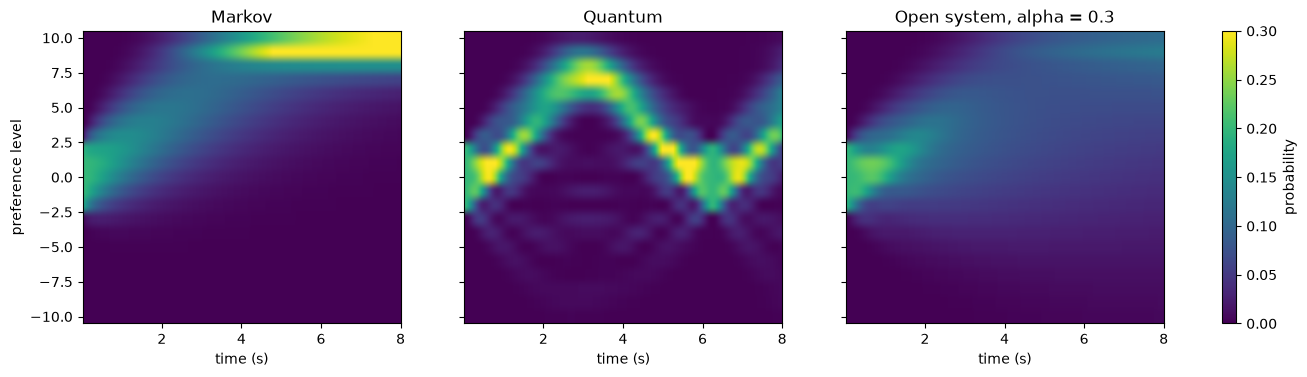

In [13]:
extent = [time_grid[0], time_grid[-1], preference_levels[0] - 0.5, preference_levels[-1] + 0.5]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (title, state_probability) in zip(axes, [("Markov", markov_state_probability), ("Quantum", quantum_state_probability), (f"Open system, alpha = {alpha}", open_system_state_probability)]):
    image = ax.imshow(state_probability.T, origin="lower", aspect="auto", extent=extent, cmap="viridis", vmin=0, vmax=0.3)
    ax.set_title(title)
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("preference level")
fig.colorbar(image, ax=axes, label="probability", fraction=0.02)
plt.show()

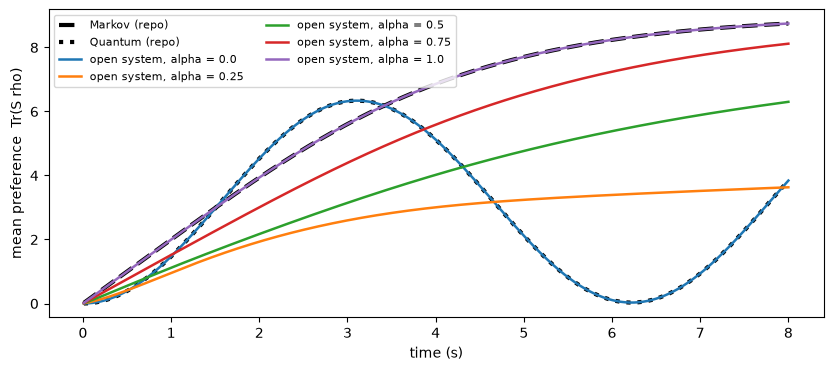

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_grid, markov_mean_preference, "k--", lw=3, label="Markov (repo)")
ax.plot(time_grid, quantum_mean_preference, "k:", lw=3, label="Quantum (repo)")
for a in alpha_grid:
    ax.plot(time_grid, expected_preference(rho_t_by_alpha[a], preference_operator), lw=1.8, label=f"open system, alpha = {a}")
ax.set_xlabel("time (s)")
ax.set_ylabel("mean preference  Tr(S rho)")
ax.legend(fontsize=8, ncol=2)
plt.show()

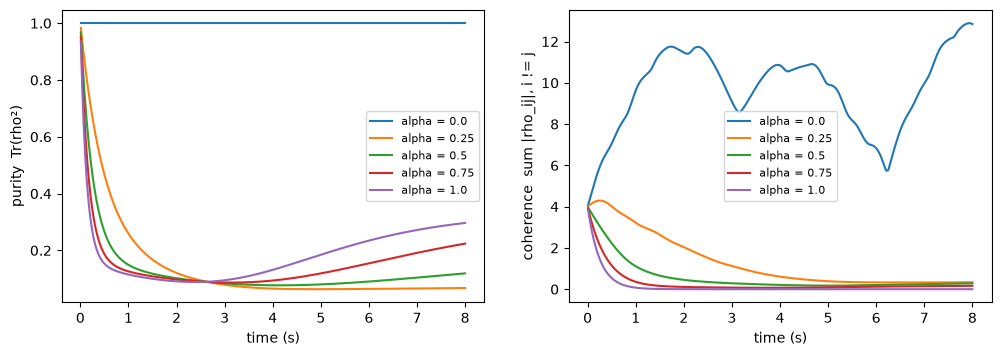

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for a in alpha_grid:
    axes[0].plot(time_grid, purity(rho_t_by_alpha[a]), label=f"alpha = {a}")
    axes[1].plot(time_grid, coherence(rho_t_by_alpha[a]), label=f"alpha = {a}")
axes[0].set_ylabel("purity  Tr(rho²)")
axes[1].set_ylabel("coherence  sum |rho_ij|, i != j")
for ax in axes:
    ax.set_xlabel("time (s)")
    ax.legend(fontsize=8)
plt.show()

## Choice vs no-choice (paper design)

Evolve to $t_1$, measure (choice) or not, then evolve for the decay-rescaled delay $\tau = (t_2 - t_1)\,e^{-\lambda (t_2 - t_1)}$ (Eq. 3, clock restarted at $t_1$).
Strength rating $S_{jj} = S_{max} / (1 + e^{-|j - mid|})$ (Eq. 4). Projectors: 1 on one side of the midpoint, $\sqrt{1/2}$ at the midpoint (Markov: $1/2$).

In [16]:
t1 = 0.5
decay_rate = 0.05
s_max = 30.0
delay_grid = np.round(np.linspace(0.05, 8.0, 160) / delta) * delta
effective_delay = np.round(delay_grid * np.exp(-decay_rate * delay_grid) / delta) * delta      # Eq. (3), snapped to the delta grid
effective_delay_ij = effective_delay[None, :]
t1_ij = np.full_like(effective_delay_ij, t1)

def preference_strength_operator(n_states, s_max):                                              # Eq. (4)
    distance_from_midpoint = np.abs(cu.get_conf_limits(n_states))
    return npx.diag(s_max / (1 + npx.exp(-distance_from_midpoint)))

strength_operator = preference_strength_operator(n_states, s_max)
strength_by_level = npx.diag(strength_operator)

project_right_quantum = Mc_quantum + Mn_quantum / npx.sqrt(2)
project_left_quantum = Mw_quantum + Mn_quantum / npx.sqrt(2)
project_right_markov = Mc_markov + Mn_markov / 2
project_left_markov = Mw_markov + Mn_markov / 2

print("P_R² + P_L² == I (Quantum):", np.allclose(project_right_quantum @ project_right_quantum + project_left_quantum @ project_left_quantum, npx.eye(n_states)))
print("P_R + P_L == I (Markov):", np.allclose(project_right_markov + project_left_markov, npx.eye(n_states)))

P_R² + P_L² == I (Quantum): True
P_R + P_L == I (Markov): True


In [17]:
def response_probability(rho, projector):                                                       # Pr(R) = Tr(P_R rho P_R†)
    return np.real(npx.trace(projector @ rho @ projector.conj().T))

def collapse_density_matrix(rho, projector):                                                    # rho_R = P_R rho P_R† / Pr(R)
    return projector @ rho @ projector.conj().T / response_probability(rho, projector)

def open_system_choice_vs_no_choice(alpha):
    superoperator = open_system_superoperator(H, K, alpha)
    rho_t1 = evolve_density_matrix(rho_0, superoperator, np.asarray([[t1]]), delta)[0]
    rho_no_choice = evolve_density_matrix(rho_t1, superoperator, effective_delay_ij, delta)

    pr_right = response_probability(rho_t1, project_right_quantum)
    pr_left = response_probability(rho_t1, project_left_quantum)
    rho_given_right = evolve_density_matrix(collapse_density_matrix(rho_t1, project_right_quantum), superoperator, effective_delay_ij, delta)
    rho_given_left = evolve_density_matrix(collapse_density_matrix(rho_t1, project_left_quantum), superoperator, effective_delay_ij, delta)
    rho_choice = pr_right * rho_given_right + pr_left * rho_given_left                          # Pr(S_j) = Pr(R) Pr(S_j | R) + Pr(L) Pr(S_j | L)

    return expected_preference(rho_no_choice, strength_operator), expected_preference(rho_choice, strength_operator)

In [18]:
def repo_choice_vs_no_choice(generator, phi_0, project_right, project_left, Mn, model_type):
    to_probability = (lambda phi: phi) if model_type == "Markov" else (lambda phi: npx.abs(phi) ** 2)

    phi_no_choice = ca.perform_state_transition(generator, RT_s=t1_ij + effective_delay_ij, RA_s=None, Mc=project_right, Mw=project_left, Mn=Mn,
                                                phi_0=phi_0, delta=delta, transition_type="RT", likelihood_type="SINGLE")
    phi_right_branch = ca.perform_state_transition(generator, RT_s=(t1_ij, effective_delay_ij), RA_s=(np.ones_like(t1_ij), None), Mc=project_right, Mw=project_left, Mn=Mn,
                                                   phi_0=phi_0, delta=delta, transition_type="RT", likelihood_type="JOINT")
    phi_left_branch = ca.perform_state_transition(generator, RT_s=(t1_ij, effective_delay_ij), RA_s=(np.zeros_like(t1_ij), None), Mc=project_right, Mw=project_left, Mn=Mn,
                                                  phi_0=phi_0, delta=delta, transition_type="RT", likelihood_type="JOINT")

    probability_no_choice = to_probability(phi_no_choice)[0, :, :, 0]
    probability_choice = (to_probability(phi_right_branch) + to_probability(phi_left_branch))[0, :, :, 0]
    return probability_no_choice @ strength_by_level, probability_choice @ strength_by_level

In [19]:
markov_no_choice, markov_choice = repo_choice_vs_no_choice(intensity_matrix, p_0, project_right_markov, project_left_markov, Mn_markov, "Markov")
quantum_no_choice, quantum_choice = repo_choice_vs_no_choice(quantum_generator, psi_0, project_right_quantum, project_left_quantum, Mn_quantum, "Quantum")
open_system_no_choice, open_system_choice = open_system_choice_vs_no_choice(alpha)

pure_markov_no_choice, pure_markov_choice = open_system_choice_vs_no_choice(1.0)
pure_quantum_no_choice, pure_quantum_choice = open_system_choice_vs_no_choice(0.0)

print("Markov: choice == no choice:", np.allclose(markov_choice, markov_no_choice))
print("alpha = 1 == repo Markov:", np.allclose(pure_markov_no_choice, markov_no_choice, atol=1e-8), np.allclose(pure_markov_choice, markov_choice, atol=1e-8))
print("alpha = 0 == repo Quantum:", np.allclose(pure_quantum_no_choice, quantum_no_choice, atol=1e-8), np.allclose(pure_quantum_choice, quantum_choice, atol=1e-8))

Markov: choice == no choice: True
alpha = 1 == repo Markov: True True
alpha = 0 == repo Quantum: True True


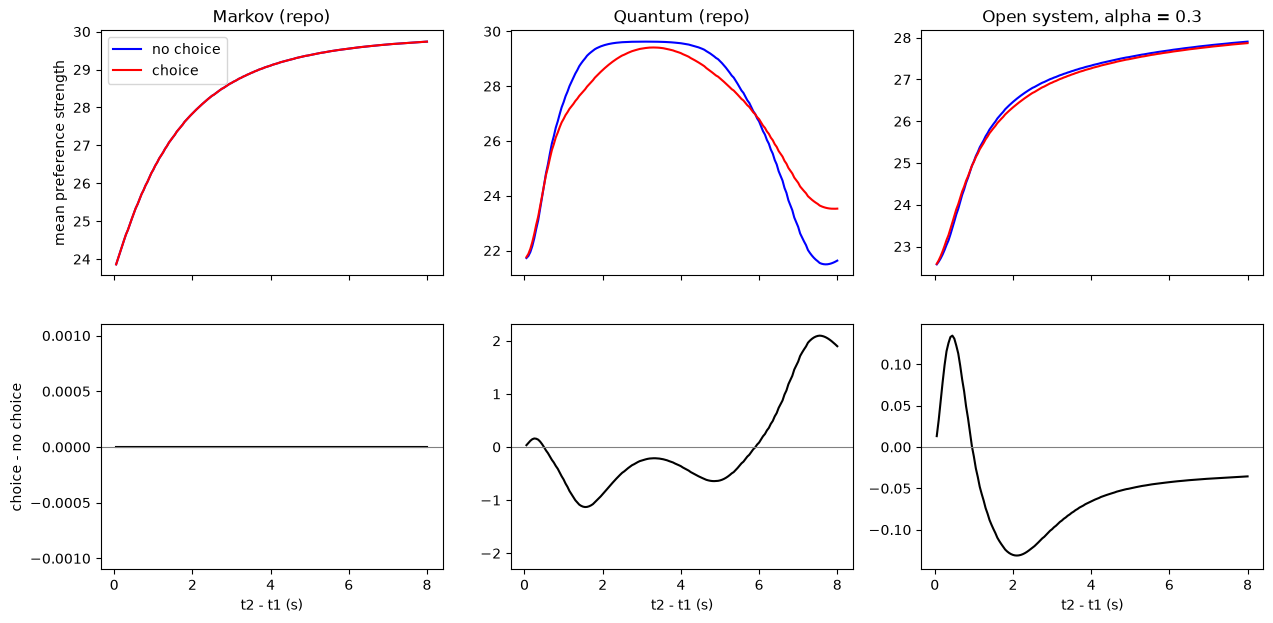

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for column, (title, no_choice, choice) in enumerate([("Markov (repo)", markov_no_choice, markov_choice),
                                                     ("Quantum (repo)", quantum_no_choice, quantum_choice),
                                                     (f"Open system, alpha = {alpha}", open_system_no_choice, open_system_choice)]):
    axes[0, column].plot(delay_grid, no_choice, "b-", label="no choice")
    axes[0, column].plot(delay_grid, choice, "r-", label="choice")
    axes[0, column].set_title(title)
    choice_effect = np.asarray(choice) - np.asarray(no_choice)
    axes[1, column].plot(delay_grid, choice_effect, "k-")
    axes[1, column].axhline(0, color="grey", lw=0.8)
    axes[1, column].set_ylim(-max(np.abs(choice_effect).max(), 1e-3) * 1.1, max(np.abs(choice_effect).max(), 1e-3) * 1.1)
    axes[1, column].set_xlabel("t2 - t1 (s)")
axes[0, 0].set_ylabel("mean preference strength")
axes[1, 0].set_ylabel("choice - no choice")
axes[0, 0].legend()
plt.show()

## Internally controlled stopping (Busemeyer, Wang & Townsend 2006, Appendix C)

A choice is checked every $\delta$: no-choice branch $\rho \to N \rho N^\dagger$, then one open-system step.
Joint probability of stopping at step $n$ with choice $R$: $\mathrm{Tr}(M_R\,\tilde\rho_n M_R^\dagger)$ with $\tilde\rho_n = E_\delta (\mathcal{N} E_\delta)^{n-1} \rho_0$, the density-matrix form of $|M_R U (N U)^{n-1} \psi_0|^2$.
Same repo call as above with `Mn = kron(N, N*)` instead of the identity.

In [21]:
response_width_stop = 4
measurement_prob = 0.75
step_counts_ij = np.arange(1, 401)[None, :]
stopping_time = step_counts_ij[0] * delta

Mc_stop_markov, Mw_stop_markov, Mn_stop_markov = ca._get_measurement_matrix(n_states, response_width_stop, prob=measurement_prob, model_type="Markov")
Mc_stop_quantum, Mw_stop_quantum, Mn_stop_quantum = ca._get_measurement_matrix(n_states, response_width_stop, prob=measurement_prob, model_type="Quantum")

def repo_stopping_density(generator, phi_0, Mc, Mw, Mn, model_type):
    to_probability = (lambda phi: phi) if model_type == "Markov" else (lambda phi: npx.abs(phi) ** 2)
    phi_survived = ca.perform_state_transition(generator, RT_s=step_counts_ij * delta, RA_s=None, Mc=Mc, Mw=Mw, Mn=Mn,
                                               phi_0=phi_0, delta=delta, transition_type="TIMESTEP", likelihood_type="SINGLE")   # I x J x S x 1
    stop_correct = np.asarray(to_probability(Mc @ phi_survived)[0, :, :, 0].sum(axis=-1))
    stop_incorrect = np.asarray(to_probability(Mw @ phi_survived)[0, :, :, 0].sum(axis=-1))
    return stop_correct, stop_incorrect

def open_system_stopping_density(alpha):
    superoperator = open_system_superoperator(H, K, alpha)
    no_choice_superoperator = sandwich_superoperator(Mn_stop_quantum, Mn_stop_quantum.conj().T)                                  # vec(N rho N†)
    rho_survived = ca.perform_state_transition(superoperator[None, None], RT_s=step_counts_ij * delta, RA_s=None, Mc=None, Mw=None, Mn=no_choice_superoperator,
                                               phi_0=vectorize(rho_0)[None, None], delta=delta, transition_type="TIMESTEP", likelihood_type="SINGLE")[0, :, :, 0].reshape(-1, n_states, n_states)
    stop_correct = response_probability_batch(rho_survived, Mc_stop_quantum)
    stop_incorrect = response_probability_batch(rho_survived, Mw_stop_quantum)
    return stop_correct, stop_incorrect

def response_probability_batch(rho_t, projector):
    return np.real(npx.trace(projector @ rho_t @ projector.conj().T, axis1=-2, axis2=-1))

In [22]:
markov_stop = repo_stopping_density(intensity_matrix, p_0, Mc_stop_markov, Mw_stop_markov, Mn_stop_markov, "Markov")
quantum_stop = repo_stopping_density(quantum_generator, psi_0, Mc_stop_quantum, Mw_stop_quantum, Mn_stop_quantum, "Quantum")
open_system_stop = open_system_stopping_density(alpha)
pure_markov_stop = open_system_stopping_density(1.0)
pure_quantum_stop = open_system_stopping_density(0.0)

print("alpha = 1 stopping densities == repo Markov TIMESTEP:", np.allclose(pure_markov_stop, markov_stop, atol=1e-10))
print("alpha = 0 stopping densities == repo Quantum TIMESTEP:", np.allclose(pure_quantum_stop, quantum_stop, atol=1e-10))
for name, (stop_correct, stop_incorrect) in [("Markov", markov_stop), ("Quantum", quantum_stop), (f"Open system alpha = {alpha}", open_system_stop)]:
    print(f"{name}: P(correct by {stopping_time[-1]:.0f} s) = {stop_correct.sum():.3f}, P(incorrect) = {stop_incorrect.sum():.3f}")

alpha = 1 stopping densities == repo Markov TIMESTEP: True
alpha = 0 stopping densities == repo Quantum TIMESTEP: True
Markov: P(correct by 4 s) = 0.677, P(incorrect) = 0.001
Quantum: P(correct by 4 s) = 0.066, P(incorrect) = 0.003
Open system alpha = 0.3: P(correct by 4 s) = 0.220, P(incorrect) = 0.012


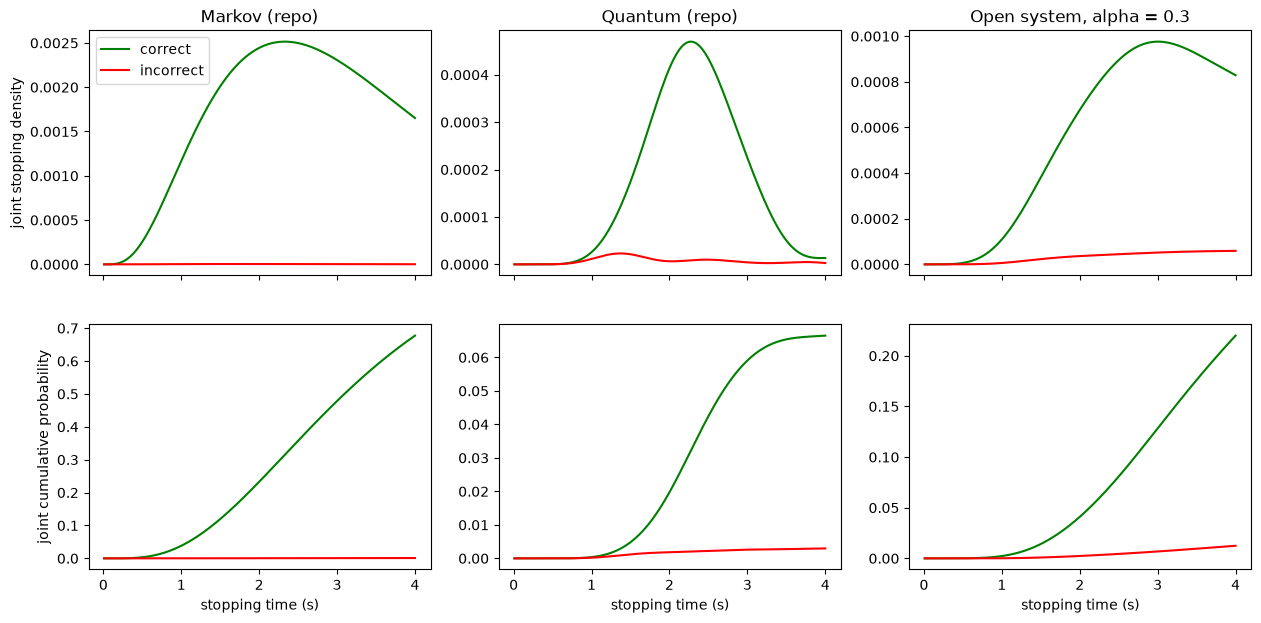

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
for column, (title, (stop_correct, stop_incorrect)) in enumerate([("Markov (repo)", markov_stop), ("Quantum (repo)", quantum_stop), (f"Open system, alpha = {alpha}", open_system_stop)]):
    axes[0, column].plot(stopping_time, stop_correct, "g-", label="correct")
    axes[0, column].plot(stopping_time, stop_incorrect, "r-", label="incorrect")
    axes[0, column].set_title(title)
    axes[1, column].plot(stopping_time, np.cumsum(stop_correct), "g-")
    axes[1, column].plot(stopping_time, np.cumsum(stop_incorrect), "r-")
    axes[1, column].set_xlabel("stopping time (s)")
axes[0, 0].set_ylabel("joint stopping density")
axes[1, 0].set_ylabel("joint cumulative probability")
axes[0, 0].legend()
plt.show()